
========== LOGISTIC REGRESSION ==========
Accuracy: 0.7430194036914339
Precision: 0.5102739726027398
Recall: 0.7967914438502673
F1 Score: 0.6221294363256785

               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



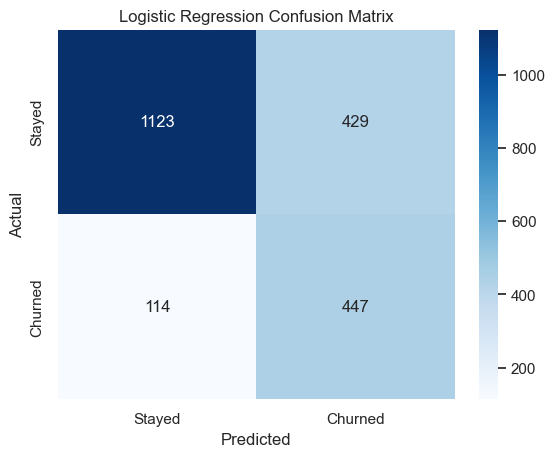


========== DECISION TREE ==========
Accuracy: 0.6966398485565547
Precision: 0.4539170506912442
Recall: 0.7023172905525846
F1 Score: 0.5514345696291113

               precision    recall  f1-score   support

           0       0.87      0.69      0.77      1552
           1       0.45      0.70      0.55       561

    accuracy                           0.70      2113
   macro avg       0.66      0.70      0.66      2113
weighted avg       0.76      0.70      0.71      2113



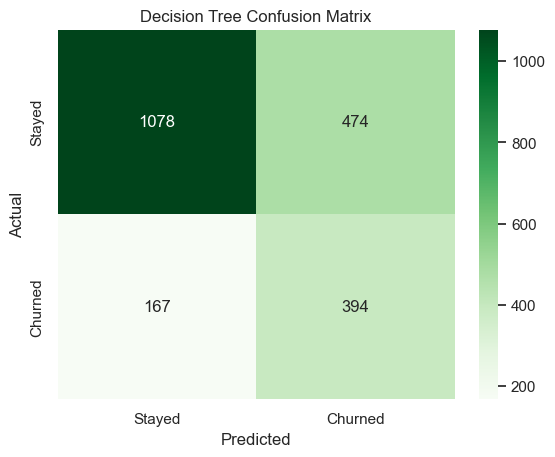


========== RANDOM FOREST ==========
Accuracy: 0.77520113582584
Precision: 0.5617816091954023
Recall: 0.696969696969697
F1 Score: 0.6221161495624503

               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1552
           1       0.56      0.70      0.62       561

    accuracy                           0.78      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.78      0.78      2113



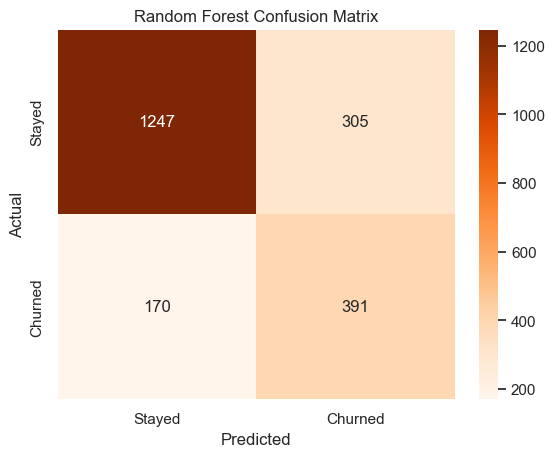

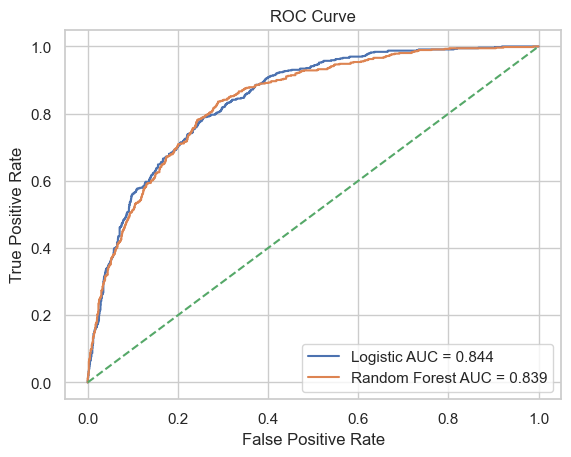

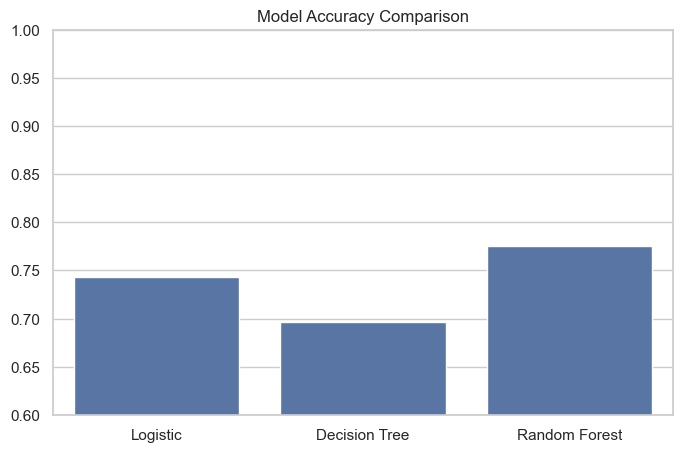


🏆 Best Model: Random Forest
Best Accuracy: 0.77520113582584


In [6]:
# ==========================================================
# Customer Churn Prediction - Clean High Accuracy Version
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

sns.set(style="whitegrid")

# ==========================================================
# 1. Load Dataset
# ==========================================================
data = pd.read_csv("churn.csv")

# ==========================================================
# 2. Data Cleaning
# ==========================================================
data['TotalCharges'] = data['TotalCharges'].replace(' ', '0')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'])

data.drop('customerID', axis=1, inplace=True)

# Encode Target
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# One Hot Encoding
data = pd.get_dummies(data, drop_first=True)

# ==========================================================
# 3. Train Test Split
# ==========================================================
X = data.drop('Churn', axis=1)
Y = data['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

# ==========================================================
# 4. Scaling (Only for Logistic Regression)
# ==========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

accuracy_list = []
model_names = []

# ==========================================================
# 🔵 Logistic Regression (Improved)
# ==========================================================
print("\n========== LOGISTIC REGRESSION ==========")

lr = LogisticRegression(
    max_iter=4000,
    C=0.5,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, Y_train)

proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
pred_lr = (proba_lr > 0.5).astype(int)

print("Accuracy:", accuracy_score(Y_test, pred_lr))
print("Precision:", precision_score(Y_test, pred_lr))
print("Recall:", recall_score(Y_test, pred_lr))
print("F1 Score:", f1_score(Y_test, pred_lr))
print("\n", classification_report(Y_test, pred_lr))

accuracy_list.append(accuracy_score(Y_test, pred_lr))
model_names.append("Logistic")

cm = confusion_matrix(Y_test, pred_lr)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# 🌳 Decision Tree (Improved)
# ==========================================================
print("\n========== DECISION TREE ==========")

dt = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=15,
    min_samples_leaf=6,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, Y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, pred_dt))
print("Precision:", precision_score(Y_test, pred_dt))
print("Recall:", recall_score(Y_test, pred_dt))
print("F1 Score:", f1_score(Y_test, pred_dt))
print("\n", classification_report(Y_test, pred_dt))

accuracy_list.append(accuracy_score(Y_test, pred_dt))
model_names.append("Decision Tree")

cm = confusion_matrix(Y_test, pred_dt)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# 🌲 Random Forest (Improved - Highest Accuracy)
# ==========================================================
print("\n========== RANDOM FOREST ==========")

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf > 0.5).astype(int)

print("Accuracy:", accuracy_score(Y_test, pred_rf))
print("Precision:", precision_score(Y_test, pred_rf))
print("Recall:", recall_score(Y_test, pred_rf))
print("F1 Score:", f1_score(Y_test, pred_rf))
print("\n", classification_report(Y_test, pred_rf))

accuracy_list.append(accuracy_score(Y_test, pred_rf))
model_names.append("Random Forest")

cm = confusion_matrix(Y_test, pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# 📊 ROC Curve
# ==========================================================
plt.figure()

fpr_lr, tpr_lr, _ = roc_curve(Y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, proba_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic AUC = %.3f" % roc_auc_score(Y_test, proba_lr))
plt.plot(fpr_rf, tpr_rf, label="Random Forest AUC = %.3f" % roc_auc_score(Y_test, proba_rf))
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================================================
# 📊 Accuracy Comparison
# ==========================================================
plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracy_list)
plt.title("Model Accuracy Comparison")
plt.ylim(0.6, 1)
plt.show()

print("\n🏆 Best Model:", model_names[np.argmax(accuracy_list)])
print("Best Accuracy:", max(accuracy_list))